In [50]:
class myNode:
  def __init__(self, val,_children=(),_op = '',_backward = lambda: None):
    self.val = val
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self._backward = _backward

  def __add__(self,other):
    if not isinstance(other,myNode):
      other = myNode(other)
    out = myNode(self.val + other.val,(self,other),'+')
    def _backward():
      self.grad+= 1.0 * out.grad
      other.grad+= 1.0 * out.grad
    out._backward = _backward
    return out

  def __sub__(self,other):
    return self+(-other)

  def __rmul__(self, other):
    return self*other
  def __radd__(self,other):
    return self+other

  def __mul__(self,other):
    if not isinstance(other,myNode):
      other = myNode(other)
    out = myNode(self.val * other.val,(self,other),'*')
    def _backward():
      self.grad += other.val * out.grad
      other.grad += self.val * out.grad
    out._backward = _backward
    return out

  def __pow__(self,other):
    out = myNode(self.val**other.val,(self,),f'**{other}')
    def _backward():
      self.grad += other * (self.val**(other-1)) * out.grad

  def tanh(self):
    out =

  def build_backward(self):
    topo = []
    vis = set()
    def build_topo(self):
      if self not in vis:
        vis.add(self)
        for child in self._prev:
          # print(f"child: {child.val}")
          build_topo(child)
        # print(f"Appending node: {self.val}")
        topo.append(self)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def __repr__(self):
    return f"myNode(val={self.val}, grad={self.grad})"



In [51]:
import graphviz as gr

G = gr.Digraph()
G.attr(rankdir='LR')

vis = set()
nodes = []
visitedNodes = []

def build_graph(root):
  if root not in vis:
    vis.add(root)
    G.node(str(id(root)), label=f"{{{str(id(root))}|val: {root.val} | grad: {root.grad} }}",shape = 'record')
    if(root._op):
      op_node_id = str(id(root)) + root._op
      G.node(op_node_id, label=f"{{{str(root._op)}}}",shape = 'record')
      G.edge(op_node_id,str(id(root)))
      for child in root._prev:
        G.edge(str(id(child)),op_node_id)
        build_graph(child)

    return G


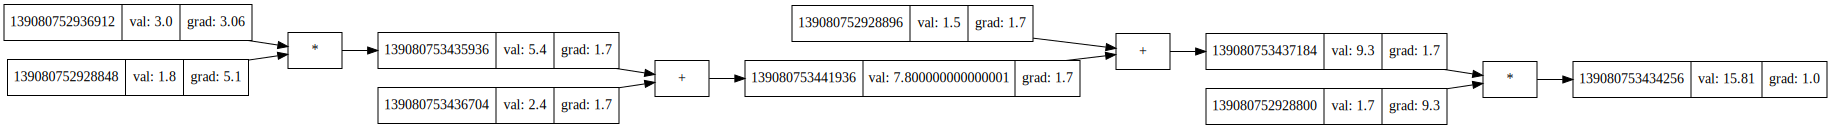

In [52]:


a = myNode(2.4)
a.label = 'a'
b = myNode(1.8)
b.label = 'b'
c = myNode(3.0)
c.label = 'c'
e = myNode(1.5)
i = myNode(1.7)

d = b * c + a
f = d + e
g = f * i


# g.grad = 1.0
g.build_backward()



d.label = 'd'
# d._show_()
G = build_graph(g)
G



In [53]:
import torch

In [54]:
a = torch.Tensor([2.4]).double() ; a.requires_grad = True
b = torch.Tensor([1.8]).double() ; b.requires_grad = True
c = torch.Tensor([3.0]).double() ; c.requires_grad = True
e = torch.Tensor([1.5]).double() ; e.requires_grad = True
i = torch.Tensor([1.7]).double() ; i.requires_grad = True

d = b*c + a
f = d+e
g = f*i
g.backward()
print(g.data.item())
print(c.grad.item())

15.810000362396238
3.0600000047683693


In [55]:
from IPython.core.formatters import IPythonDisplayFormatter
import random
class Neuron:
  def __init__(self,n):
    self.w = [myNode(random.uniform(-1,1)) for _ in range(n)]
    self._b = myNode(random.uniform(-1,1))
  def _parameters_(self):
    return self.w + [self._b]
  def __call__(self,x):
    inter = sum((wi*item for wi,item in zip(self.w,x)),self._b)
    return inter

class Layer():
  def __init__(self,nin,nouts):
    self.neurons = [Neuron(nin) for _ in range(nouts)]
  def _params_(self):
    params = []
    for neuron in self.neurons:
      params.append(neuron._parameters_())
    return params
  def __call__(self,x):
    outs = [neuron(x) for neuron in self.neurons]
    return outs

class MLP():
  def __init__(self,nin,nouts):
   sizeArray = [nin] + nouts
   self.layers = [Layer(sizeArray[i],sizeArray[i+1]) for i in range(len(nouts))]
  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x[0] if len(x) == 1 else x
  def _weights_(self):
    out = []
    for layer in self.layers:
      for pr in layer._params_():
       out.extend(pr)
    return out

# output.build_backward()

# G1 = build_graph(output)

# G1

# a = Layer(2,3)asdf
# a(x)





In [56]:

x = [2.0,1.5,-0.5]
a = MLP(3,[4,4,1])
output = a(x)
a._weights_()

[myNode(val=0.8025340590388084, grad=0.0),
 myNode(val=0.4090098980965853, grad=0.0),
 myNode(val=0.15170776873980607, grad=0.0),
 myNode(val=0.6478732114087025, grad=0.0),
 myNode(val=-0.10534896182188036, grad=0.0),
 myNode(val=-0.49285863899666604, grad=0.0),
 myNode(val=0.9937829234572295, grad=0.0),
 myNode(val=0.2534921096605134, grad=0.0),
 myNode(val=0.6564527939712981, grad=0.0),
 myNode(val=-0.7794341130378994, grad=0.0),
 myNode(val=0.689041169127572, grad=0.0),
 myNode(val=0.582659907055707, grad=0.0),
 myNode(val=0.8352642040376261, grad=0.0),
 myNode(val=-0.9545352433917456, grad=0.0),
 myNode(val=0.6525841093293654, grad=0.0),
 myNode(val=0.8336032145599495, grad=0.0),
 myNode(val=0.05725966742190414, grad=0.0),
 myNode(val=0.9146633679946374, grad=0.0),
 myNode(val=-0.05043789609603877, grad=0.0),
 myNode(val=0.8446053810102896, grad=0.0),
 myNode(val=0.21121125592447787, grad=0.0),
 myNode(val=0.24813828149780237, grad=0.0),
 myNode(val=-0.11016602802317932, grad=0.0),

In [57]:
xs = [[1.5,2,8,-0.7],[3.4,2.8,-7.6],[3.5,3.2,-0,1]]

pred = [-1.0,2,0,1]

groundTruths = []
for input in xs:
  groundTruths.append(a(input))


for i in range(len(groundTruths)):
  loss +=

